In [26]:
import numpy as np
import matplotlib.pyplot as plt

Slope: -0.2432924222345238, Intercept: 4.985348488439048


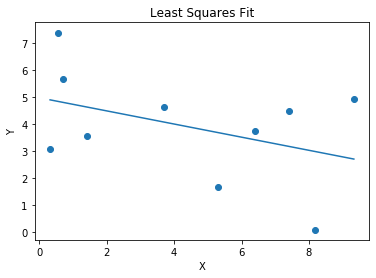

In [27]:
from numpy import random

X = np.random.uniform(low=0.0, high=10., size= 10)
X= np.sort(X)

Y= np.random.uniform(low=0.0, high=10., size= 10)
A = np.vstack([X, np.ones(len(X))]).T

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

plt.scatter(X, Y)
plt.title("Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(X, m*X+c)
plt.show()


In [28]:
#Mean Square Value
ls_mse = np.mean((Y - m*X +c)**2)
print(f'Mean Squared Error: {ls_mse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - m*X +c)**2)
ls_r2 = 1 - (ss_res / ss_total)
print(f'R-squared: {ls_r2:.4f}')

Mean Squared Error: 102.5312
R-squared: -26.3430


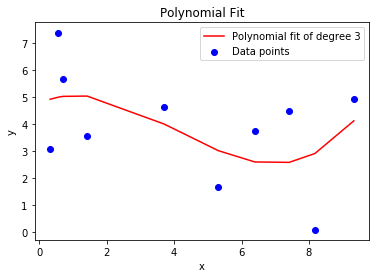

In [29]:
degree = 3
coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(X)
# Step 4: Plotting the results
plt.scatter(X, Y, color='blue', label='Data points') # Original data points
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [30]:
#Mean Square Value
poly_mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error: {poly_mse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
poly_r2 = 1 - (ss_res / ss_total)
print(f'R-squared: {poly_r2:.4f}')

Mean Squared Error: 2.7432
R-squared: 0.2684


In [31]:
if poly_mse < ls_mse:
    better_mse = "Polynomial Fit"
else:
    better_mse = "Least Square Fit"

if abs(1-poly_r2) < abs(1-ls_r2):
    better_r2 = "Polynomial Fit"
else:
    better_r2 = "Least Square Fit"
    
    
print("\nBetter fit based on MSE:", better_mse)
print("Better fit based on R^2:", better_r2)



Better fit based on MSE: Polynomial Fit
Better fit based on R^2: Polynomial Fit


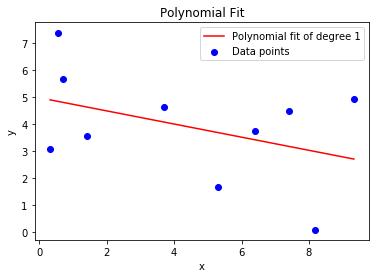

Mean Squared Error of Degree 1: 3.1164
R-squared of Degree 1: 0.1689


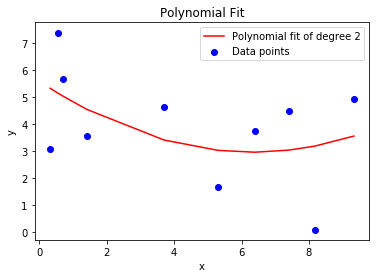

Mean Squared Error of Degree 2: 2.8955
R-squared of Degree 2: 0.2278


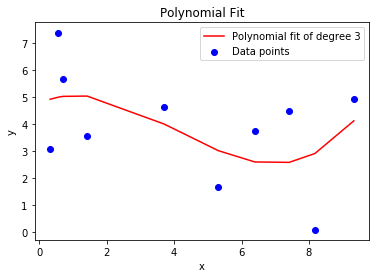

Mean Squared Error of Degree 3: 2.7432
R-squared of Degree 3: 0.2684


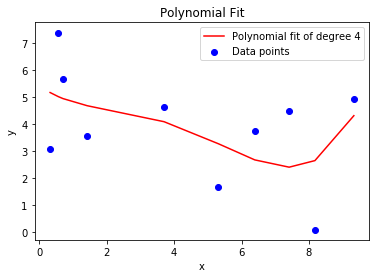

Mean Squared Error of Degree 4: 2.7019
R-squared of Degree 4: 0.2795


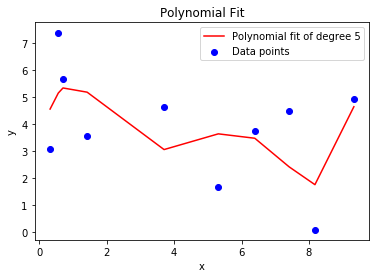

Mean Squared Error of Degree 5: 2.3470
R-squared of Degree 5: 0.3741


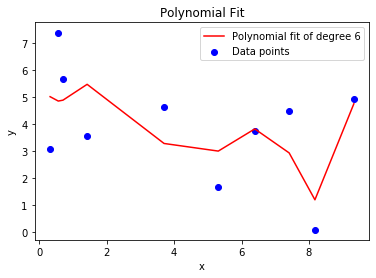

Mean Squared Error of Degree 6: 2.1710
R-squared of Degree 6: 0.4211


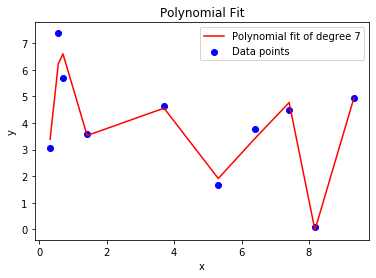

Mean Squared Error of Degree 7: 0.2601
R-squared of Degree 7: 0.9306


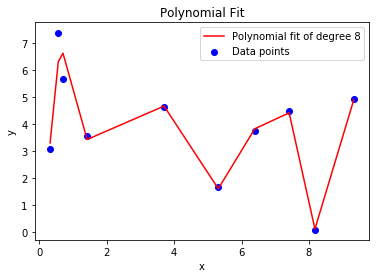

Mean Squared Error of Degree 8: 0.2155
R-squared of Degree 8: 0.9425


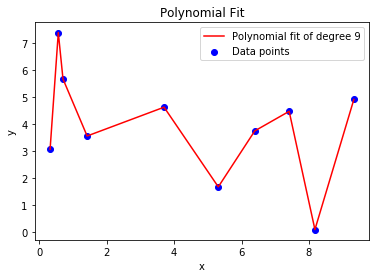

Mean Squared Error of Degree 9: 0.0000
R-squared of Degree 9: 1.0000


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


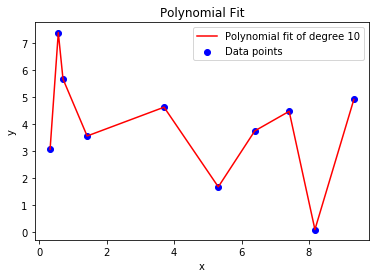

Mean Squared Error of Degree 10: 0.0000
R-squared of Degree 10: 1.0000


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


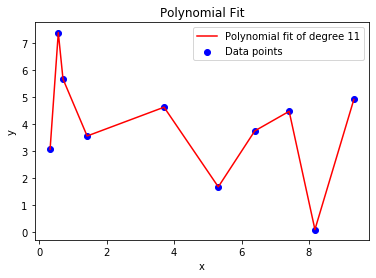

Mean Squared Error of Degree 11: 0.0000
R-squared of Degree 11: 1.0000


In [32]:
for i in range(1,12):
    coefficients = np.polyfit(X, Y, i)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(X)

    plt.scatter(X, Y, color='blue', label='Data points') # Original data points
    plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {i}')
    # Fitted curve
    plt.title('Polynomial Fit')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    
    poly_mse = np.mean((Y - y_pred)**2)
    print(f'Mean Squared Error of Degree {i}: {poly_mse:.4f}')

    # R-squared value
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y_pred)**2)
    poly_r2 = 1 - (ss_res / ss_total)
    print(f'R-squared of Degree {i}: {poly_r2:.4f}')

In [33]:
#Part C: Vandermonde

In [49]:
V = np.vander(X, N= len(X), increasing=True)
# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_Y = np.dot(V.T, Y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_Y)

y_vander = np.dot(V,coefficients)
print(y_vander.shape)

(10,)


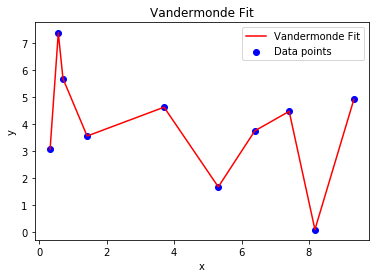

In [50]:
plt.scatter(X, Y, color='blue', label='Data points') # Original data points
plt.plot(X, y_vander, color='red', label=f'Vandermonde Fit')

plt.title('Vandermonde Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [51]:
mse = np.mean((Y - y_vander)**2)
print("MSE:", mse)

ss_res = np.sum((Y - y_vander)**2)
ss_tot = np.sum((Y - np.mean(Y))**2)

r2 = 1 - (ss_res / ss_tot)

print("R^2:", r2)

MSE: 3.1911293099052393e-05
R^2: 0.999991489903303


Looks nice. $R^2$ might be a little too close to 1.